In [1]:
"""
HYBRID RESNET50 + VISION TRANSFORMER FOR PNEUMOTHORAX DETECTION
================================================================

This notebook integrates Vision Transformer with ResNet-50 baseline to leverage:
- ResNet-50: Local feature extraction (convolutional inductive bias)
- Vision Transformer: Global feature extraction (self-attention mechanisms)

Architecture Benefits:
1. Local-to-Global Feature Fusion
2. Better handling of spatial relationships in medical images
3. Improved pneumothorax detection through attention mechanisms
"""

import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================================
# CELL 2: VISION TRANSFORMER COMPONENTS
# ============================================================================

class PatchExtractor(layers.Layer):
    """Extract patches from images for Vision Transformer"""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches
    
    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEncoder(layers.Layer):
    """Encode patches with position embeddings"""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config


class MultiHeadAttentionBlock(layers.Layer):
    """Multi-head self-attention block with normalization"""
    def __init__(self, projection_dim, num_heads, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=projection_dim // num_heads,
            dropout=dropout_rate
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(projection_dim * 2, activation=tf.nn.gelu),
            layers.Dropout(dropout_rate),
            layers.Dense(projection_dim),
            layers.Dropout(dropout_rate),
        ])

    def call(self, encoded_patches, training=False):
        # Layer norm + attention
        x1 = self.norm1(encoded_patches)
        attention_output = self.attn(x1, x1, training=training)
        x2 = layers.add([attention_output, encoded_patches])
        
        # Layer norm + MLP
        x3 = self.norm2(x2)
        x3 = self.mlp(x3, training=training)
        output = layers.add([x3, x2])
        return output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "projection_dim": self.projection_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout_rate
        })
        return config

In [ ]:
# ============================================================================
# CELL 3: CONFIGURATION (Optimized for Hybrid Architecture)
# ============================================================================

# Dataset configuration
IMAGE_SIZE = 224  # Standard for both ResNet and ViT
BATCH_SIZE = 16   # Reduced due to ViT memory requirements
EPOCHS = 50       # Adjusted for hybrid model

# ResNet Configuration
RESNET_LEARNING_RATE = 0.0001  # Lower for pre-trained ResNet

# Vision Transformer Configuration
PATCH_SIZE = 16              # 16x16 patches (224/16 = 14 patches per side)
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2  # 196 patches
PROJECTION_DIM = 256         # ViT projection dimension
NUM_HEADS = 8                # Number of attention heads
TRANSFORMER_LAYERS = 4       # Number of transformer blocks
VIT_DROPOUT = 0.1           # ViT dropout rate

# Hybrid Model Configuration
FUSION_DROPOUT = 0.3        # Dropout for fusion layer

print(f"\n{'='*80}")
print("HYBRID RESNET50 + VISION TRANSFORMER CONFIGURATION")
print(f"{'='*80}")
print(f"\n📊 Dataset Configuration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")

print(f"\n🔬 ResNet-50 Configuration:")
print(f"  Learning Rate: {RESNET_LEARNING_RATE}")
print(f"  Purpose: Local feature extraction")

print(f"\n🎯 Vision Transformer Configuration:")
print(f"  Patch Size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"  Number of Patches: {NUM_PATCHES}")
print(f"  Projection Dimension: {PROJECTION_DIM}")
print(f"  Attention Heads: {NUM_HEADS}")
print(f"  Transformer Layers: {TRANSFORMER_LAYERS}")
print(f"  Purpose: Global feature extraction")

print(f"\n🔗 Fusion Configuration:")
print(f"  Fusion Dropout: {FUSION_DROPOUT}")
print(f"{'='*80}\n")


HYBRID RESNET50 + VISION TRANSFORMER CONFIGURATION

📊 Dataset Configuration:
  Image Size: 224x224
  Batch Size: 16
  Epochs: 50

🔬 ResNet-50 Configuration:
  Learning Rate: 0.0001
  Purpose: Local feature extraction

🎯 Vision Transformer Configuration:
  Patch Size: 16x16
  Number of Patches: 196
  Projection Dimension: 256
  Attention Heads: 8
  Transformer Layers: 4
  Purpose: Global feature extraction

🔗 Fusion Configuration:
  Fusion Dropout: 0.3



In [4]:
# ============================================================================
# CELL 4: DATASET LOADING (Same as baseline)
# ============================================================================

BASE_DIR = "./dataset_pneumothorax/"
CSV_PATH = os.path.join(BASE_DIR, "balanced_dataset.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"Loading balanced Pneumothorax dataset...")

try:
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Loaded CSV with {len(df):,} total images")
except Exception as e:
    print(f"✗ Error reading CSV {CSV_PATH}: {e}")
    exit(1)

print(f"\n=== Dataset Structure ===")
print(f"Columns: {df.columns.tolist()}")

if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)
else:
    print("✗ Could not find Pneumothorax labels")
    exit(1)

df['path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))
df['exists'] = df['path'].apply(os.path.exists)
missing_count = (~df['exists']).sum()

if missing_count > 0:
    print(f"\n⚠ Warning: {missing_count} images not found")
    df = df[df['exists']].copy()

df = df.drop(columns=['exists'])
balanced_df = df.copy()

print(f"\n=== Final Dataset Summary ===")
print(f"Total images: {len(df):,}")
print(f"Pneumothorax (Positive): {df['binary_label'].sum():,} ({df['binary_label'].sum()/len(df)*100:.1f}%)")
print(f"No Pneumothorax (Negative): {(len(df) - df['binary_label'].sum()):,}")

Loading balanced Pneumothorax dataset...
✓ Loaded CSV with 10,604 total images

=== Dataset Structure ===
Columns: ['Image_Index', 'Finding_Labels', 'Pneumothorax', 'Path', 'Binary_Label']

=== Final Dataset Summary ===
Total images: 10,604
Pneumothorax (Positive): 5,302 (50.0%)
No Pneumothorax (Negative): 5,302


In [5]:
# ============================================================================
# CELL 5: DATASET SPLITTING
# ============================================================================

train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['binary_label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['binary_label']
)

print(f"\n=== Dataset Splits (Stratified) ===")
print(f"Training: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}")

os.makedirs('./output', exist_ok=True)
test_df.to_csv('./output/pneumothorax_test_set_vit.csv', index=False)


=== Dataset Splits (Stratified) ===
Training: 8,483 | Validation: 1,060 | Test: 1,061


In [6]:
# ============================================================================
# CELL 6: ENHANCED DATA PIPELINE
# ============================================================================

def create_tf_dataset(df, batch_size, shuffle=True, augment=True):
    """Enhanced tf.data pipeline with medical image augmentation"""
    
    def load_and_preprocess(image_path, label):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        if augment:
            # Medical-specific augmentation
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
            img = tf.image.random_brightness(img, max_delta=0.15)
            img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
            
            # Random zoom
            if tf.random.uniform([]) > 0.5:
                crop_size = tf.random.uniform([], 0.85, 1.0)
                h, w = IMAGE_SIZE, IMAGE_SIZE
                crop_h = tf.cast(h * crop_size, tf.int32)
                crop_w = tf.cast(w * crop_size, tf.int32)
                img = tf.image.random_crop(img, [crop_h, crop_w, 3])
                img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        # Normalize to [-1, 1] for both ResNet and ViT
        img = tf.keras.applications.resnet_v2.preprocess_input(img)
        return img, label
    
    image_paths = df['path'].values
    labels = df['binary_label'].values.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=2000, seed=42)
    
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

print("Creating tf.data pipelines...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, shuffle=False, augment=False)
test_dataset = create_tf_dataset(test_df, BATCH_SIZE, shuffle=False, augment=False)

print(f"✅ Pipelines created:")
print(f"  Training batches: {len(train_dataset)}")
print(f"  Validation batches: {len(val_dataset)}")
print(f"  Test batches: {len(test_dataset)}")

Creating tf.data pipelines...
✅ Pipelines created:
  Training batches: 531
  Validation batches: 67
  Test batches: 67


In [7]:
# ============================================================================
# CELL 7: HYBRID RESNET50 + VISION TRANSFORMER ARCHITECTURE
# ============================================================================

def create_hybrid_resnet_vit_model(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    patch_size=PATCH_SIZE,
    num_patches=NUM_PATCHES,
    projection_dim=PROJECTION_DIM,
    num_heads=NUM_HEADS,
    transformer_layers=TRANSFORMER_LAYERS,
    vit_dropout=VIT_DROPOUT,
    fusion_dropout=FUSION_DROPOUT
):
    """
    Hybrid Architecture: ResNet-50 + Vision Transformer
    
    Architecture Flow:
    1. Input Image (224x224x3)
    2. ResNet-50 Branch: Local feature extraction → Feature vector (2048D)
    3. ViT Branch: Patch extraction → Transformer → Global features (256D)
    4. Feature Fusion: Concatenate ResNet + ViT features
    5. Classification Head: Dense layers → Binary prediction
    
    Key Benefits:
    - ResNet: Captures local patterns, edges, textures (pneumothorax borders)
    - ViT: Captures global context, spatial relationships (overall lung structure)
    - Fusion: Combines complementary features for robust classification
    """
    
    inputs = layers.Input(shape=input_shape, name='input_image')
    
    # ========================================================================
    # BRANCH 1: RESNET-50 (Local Feature Extraction)
    # ========================================================================
    resnet_base = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling='avg'  # Global average pooling
    )
    resnet_base.trainable = False  # Freeze initially
    
    # ResNet features (2048-dimensional)
    resnet_features = resnet_base(inputs, training=False)
    resnet_features = layers.Dropout(0.2, name='resnet_dropout')(resnet_features)
    
    # ========================================================================
    # BRANCH 2: VISION TRANSFORMER (Global Feature Extraction)
    # ========================================================================
    
    # Extract patches from input image
    patches = PatchExtractor(patch_size)(inputs)
    
    # Encode patches with positional embeddings
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    
    # Stack Transformer blocks
    vit_features = encoded_patches
    for i in range(transformer_layers):
        vit_features = MultiHeadAttentionBlock(
            projection_dim=projection_dim,
            num_heads=num_heads,
            dropout_rate=vit_dropout,
            name=f'transformer_block_{i}'
        )(vit_features)
    
    # Global average pooling over patches
    vit_features = layers.GlobalAveragePooling1D(name='vit_gap')(vit_features)
    vit_features = layers.Dropout(vit_dropout, name='vit_dropout')(vit_features)
    
    # ========================================================================
    # FEATURE FUSION: Combine ResNet + ViT features
    # ========================================================================
    
    # Concatenate features from both branches
    fused_features = layers.Concatenate(name='feature_fusion')([
        resnet_features,  # 2048D - local features
        vit_features      # 256D - global features
    ])
    
    # Total: 2304-dimensional feature vector
    
    # Dense fusion layers
    x = layers.Dense(512, activation='relu', name='fusion_dense_1')(fused_features)
    x = layers.Dropout(fusion_dropout, name='fusion_dropout_1')(x)
    x = layers.Dense(128, activation='relu', name='fusion_dense_2')(x)
    x = layers.Dropout(fusion_dropout, name='fusion_dropout_2')(x)
    
    # ========================================================================
    # CLASSIFICATION HEAD
    # ========================================================================
    outputs = layers.Dense(
        1,
        activation='sigmoid',
        kernel_regularizer=tf.keras.regularizers.l2(0.01),
        name='pneumothorax_prediction'
    )(x)
    
    model = keras.Model(inputs, outputs, name='HybridResNet50_ViT')
    
    return model, resnet_base


print("\n" + "="*80)
print("BUILDING HYBRID RESNET50 + VISION TRANSFORMER MODEL")
print("="*80)

model, resnet_base = create_hybrid_resnet_vit_model()

print(f"\n📐 Model Architecture Summary:")
print(f"  Total parameters: {model.count_params():,}")
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  ResNet base frozen: {not resnet_base.trainable}")

print(f"\n🔍 Feature Dimensions:")
print(f"  ResNet-50 features: 2048D (local)")
print(f"  ViT features: {PROJECTION_DIM}D (global)")
print(f"  Fused features: {2048 + PROJECTION_DIM}D")

print("\n" + "="*80)

# Optional: Display model architecture
model.summary()


BUILDING HYBRID RESNET50 + VISION TRANSFORMER MODEL

📐 Model Architecture Summary:
  Total parameters: 27,166,209
  Trainable parameters: 3,601,409
  ResNet base frozen: True

🔍 Feature Dimensions:
  ResNet-50 features: 2048D (local)
  ViT features: 256D (global)
  Fused features: 2304D

Model: "HybridResNet50_ViT"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 patch_extractor (PatchExtracto  (None, None, 768)   0           ['input_image[0][0]']            
 r)                                                                                     

In [8]:
# ============================================================================
# CELL 8: CLASS WEIGHTS CALCULATION
# ============================================================================

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['binary_label']),
    y=train_df['binary_label']
)
class_weights = dict(enumerate(class_weights_array))

print(f"\nClass weights: {class_weights}")


Class weights: {0: 1.000117896722471, 1: 0.9998821310702499}


In [9]:
# ============================================================================
# CELL 9: MODEL COMPILATION
# ============================================================================

model.compile(
    optimizer=Adam(learning_rate=RESNET_LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')
    ]
)

print("\n✅ Model compiled successfully")
print(f"  Optimizer: Adam (lr={RESNET_LEARNING_RATE})")
print(f"  Loss: Binary Cross-Entropy")
print(f"  Class weights: Applied")


✅ Model compiled successfully
  Optimizer: Adam (lr=0.0001)
  Loss: Binary Cross-Entropy
  Class weights: Applied


In [10]:
# ============================================================================
# CELL 10: CALLBACKS (Optimized for Hybrid Model)
# ============================================================================

callbacks = [
    ModelCheckpoint(
        filepath='./output/hybrid_resnet_vit_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    EarlyStopping(
        monitor='val_auc',
        patience=10,  # Reduced for hybrid model
        mode='max',
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
# ============================================================================
# CELL 11: THREE-STAGE TRAINING STRATEGY
# ============================================================================

print("\n" + "="*80)
print("THREE-STAGE HYBRID TRAINING STRATEGY")
print("="*80)
print("Stage 1: Train ViT + Classification Head (ResNet frozen)")
print("Stage 2: Fine-tune ResNet top layers + ViT")
print("Stage 3: Fine-tune entire network (optional)")
print("="*80 + "\n")

# STAGE 1: Train ViT and fusion layers (ResNet frozen)
print("\n" + "="*80)
print("STAGE 1: Training ViT Branch (ResNet Frozen)")
print("="*80)
print("Purpose: Let ViT learn global features independently")
print("="*80 + "\n")

history_stage1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# STAGE 2: Unfreeze ResNet top layers
print("\n" + "="*80)
print("STAGE 2: Fine-tuning ResNet + ViT")
print("="*80)

# Unfreeze last 30 layers of ResNet
for layer in resnet_base.layers[-30:]:
    layer.trainable = True

print(f"Unfrozen ResNet layers: Last 30 layers")
print(f"Total trainable params: {sum([tf.size(v).numpy() for v in model.trainable_variables]):,}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=RESNET_LEARNING_RATE * 0.1),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

history_stage2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    initial_epoch=10,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Combine histories
history = history_stage1
for key in history_stage2.history.keys():
    history.history[key].extend(history_stage2.history[key])

model.save('./output/hybrid_resnet_vit_final.keras')

print("\n✅ Training complete!")
print("Models saved:")
print("  - Best: ./output/hybrid_resnet_vit_best.keras")
print("  - Final: ./output/hybrid_resnet_vit_final.keras")


THREE-STAGE HYBRID TRAINING STRATEGY
Stage 1: Train ViT + Classification Head (ResNet frozen)
Stage 2: Fine-tune ResNet top layers + ViT
Stage 3: Fine-tune entire network (optional)


STAGE 1: Training ViT Branch (ResNet Frozen)
Purpose: Let ViT learn global features independently

Epoch 1/15
531/531 [==============================] - ETA: 0s - loss: 0.6925 - binary_accuracy: 0.5959 - auc: 0.6385 - precision: 0.5953 - recall: 0.5992 - accuracy: 0.5959
Epoch 1: val_auc improved from -inf to 0.77247, saving model to ./output\hybrid_resnet_vit_best.keras
531/531 [==============================] - 90s 140ms/step - loss: 0.6925 - binary_accuracy: 0.5959 - auc: 0.6385 - precision: 0.5953 - recall: 0.5992 - accuracy: 0.5959 - val_loss: 0.6024 - val_binary_accuracy: 0.7104 - val_auc: 0.7725 - val_precision: 0.7132 - val_recall: 0.7038 - val_accuracy: 0.7104 - lr: 1.0000e-04
Epoch 2/15
530/531 [============================>.] - ETA: 0s - loss: 0.6587 - binary_accuracy: 0.6336 - auc: 0.6832 - p

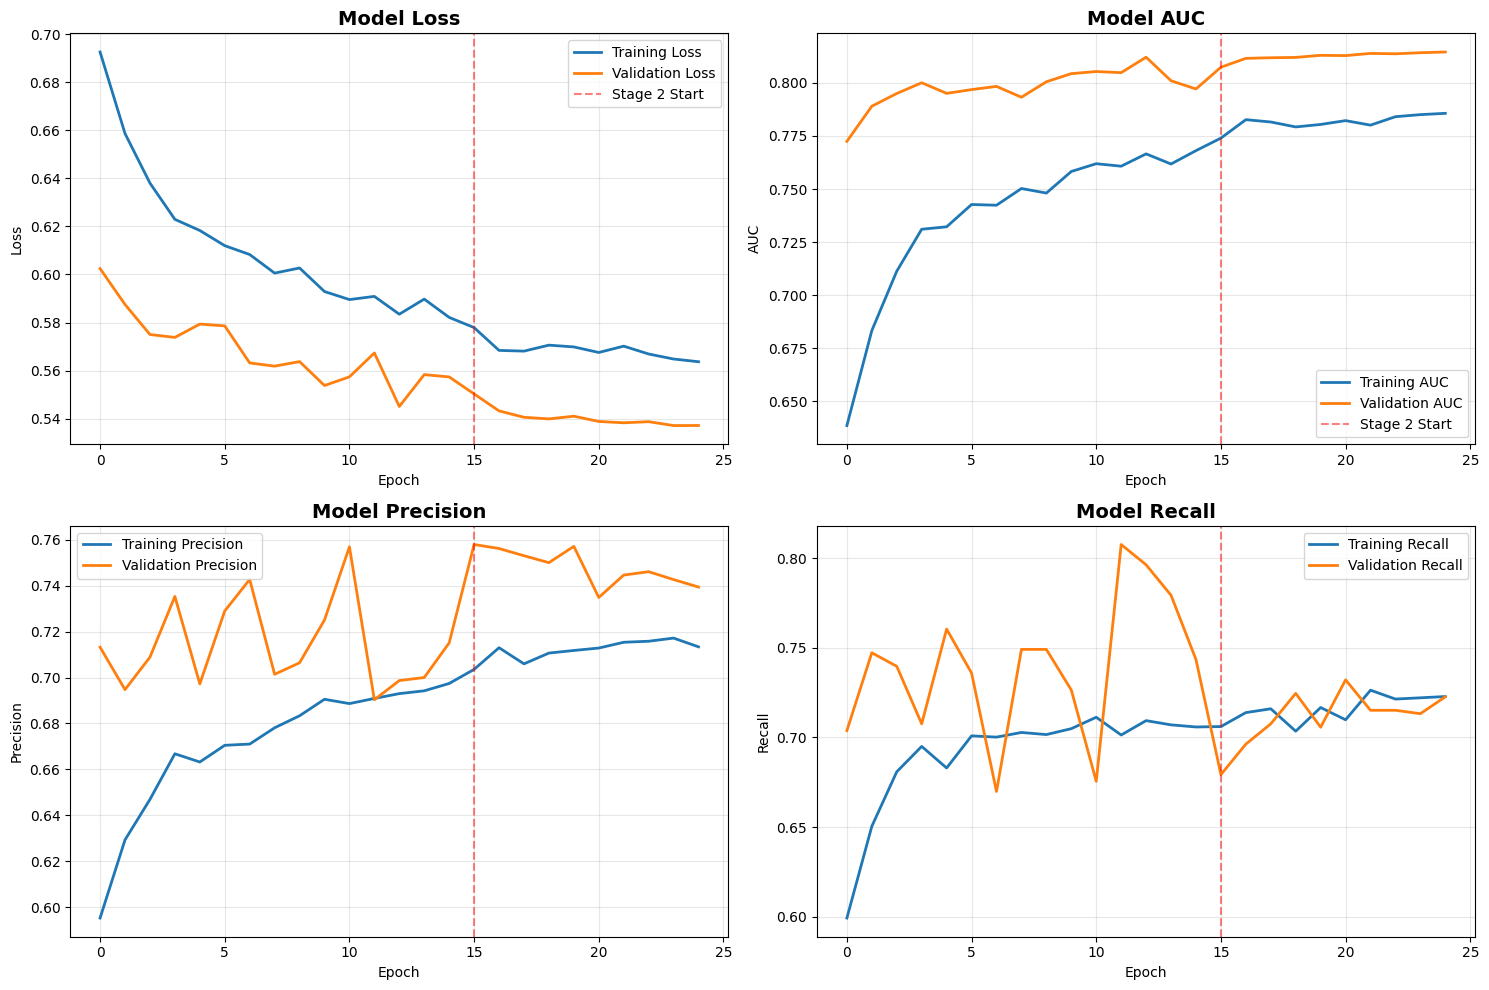

In [12]:
# ============================================================================
# CELL 12: VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Stage 2 Start')
    axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC', linewidth=2)
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
    axes[0, 1].axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Stage 2 Start')
    axes[0, 1].set_title('Model AUC', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
    axes[1, 0].axvline(x=15, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
    axes[1, 1].axvline(x=15, color='red', linestyle='--', alpha=0.5)
    axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/hybrid_vit_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [13]:
# ============================================================================
# CELL 13: COMPREHENSIVE EVALUATION
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION - HYBRID MODEL")
print("="*80)

# Load best model
best_model = keras.models.load_model('./output/hybrid_resnet_vit_best.keras', 
                                     custom_objects={
                                         'PatchExtractor': PatchExtractor,
                                         'PatchEncoder': PatchEncoder,
                                         'MultiHeadAttentionBlock': MultiHeadAttentionBlock
                                     })

# Validation set evaluation
print("\nValidation Set Evaluation...")
val_predictions = best_model.predict(val_dataset, verbose=1)
y_val_true = val_df['binary_label'].values
y_val_pred_probs = val_predictions.flatten()
y_val_pred = (y_val_pred_probs > 0.5).astype(int)

val_auc = roc_auc_score(y_val_true, y_val_pred_probs)
val_report = classification_report(y_val_true, y_val_pred, 
                                   target_names=['No Pneumothorax', 'Pneumothorax'],
                                   output_dict=True)

print(f"\n📊 VALIDATION METRICS:")
print(f"  AUC Score: {val_auc:.4f}")
print(f"  Accuracy: {val_report['accuracy']:.4f}")
print(f"  Precision: {val_report['Pneumothorax']['precision']:.4f}")
print(f"  Recall: {val_report['Pneumothorax']['recall']:.4f}")
print(f"  F1-Score: {val_report['Pneumothorax']['f1-score']:.4f}")

# Test set evaluation
print("\n" + "="*80)
print("FINAL TEST SET EVALUATION")
print("="*80)

test_predictions = best_model.predict(test_dataset, verbose=1)
y_test_true = test_df['binary_label'].values
y_test_pred_probs = test_predictions.flatten()
y_test_pred = (y_test_pred_probs > 0.5).astype(int)

test_auc = roc_auc_score(y_test_true, y_test_pred_probs)
test_report = classification_report(y_test_true, y_test_pred,
                                    target_names=['No Pneumothorax', 'Pneumothorax'])

print(f"\n🎯 FINAL TEST METRICS:")
print(f"  AUC Score: {test_auc:.4f}")
print(f"\nDetailed Classification Report:")
print(test_report)

# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives: {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives: {cm[1,1]}")

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"\n  Sensitivity: {sensitivity:.4f}")
print(f"  Specificity: {specificity:.4f}")

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE")
print("="*80)


COMPREHENSIVE EVALUATION - HYBRID MODEL

Validation Set Evaluation...
67/67 [==============================] - 5s 51ms/step

📊 VALIDATION METRICS:
  AUC Score: 0.8146
  Accuracy: 0.7340
  Precision: 0.7394
  Recall: 0.7226
  F1-Score: 0.7309

FINAL TEST SET EVALUATION
67/67 [==============================] - 3s 50ms/step

🎯 FINAL TEST METRICS:
  AUC Score: 0.7952

Detailed Classification Report:
                 precision    recall  f1-score   support

No Pneumothorax       0.73      0.73      0.73       531
   Pneumothorax       0.73      0.73      0.73       530

       accuracy                           0.73      1061
      macro avg       0.73      0.73      0.73      1061
   weighted avg       0.73      0.73      0.73      1061


Confusion Matrix:
  True Negatives: 387
  False Positives: 144
  False Negatives: 144
  True Positives: 386

  Sensitivity: 0.7283
  Specificity: 0.7288

✅ EVALUATION COMPLETE


Generating predictions on test set...
67/67 [==============================] - 5s 53ms/step
Test predictions shape: (1061,)
Test dataframe shape: (1061, 7)


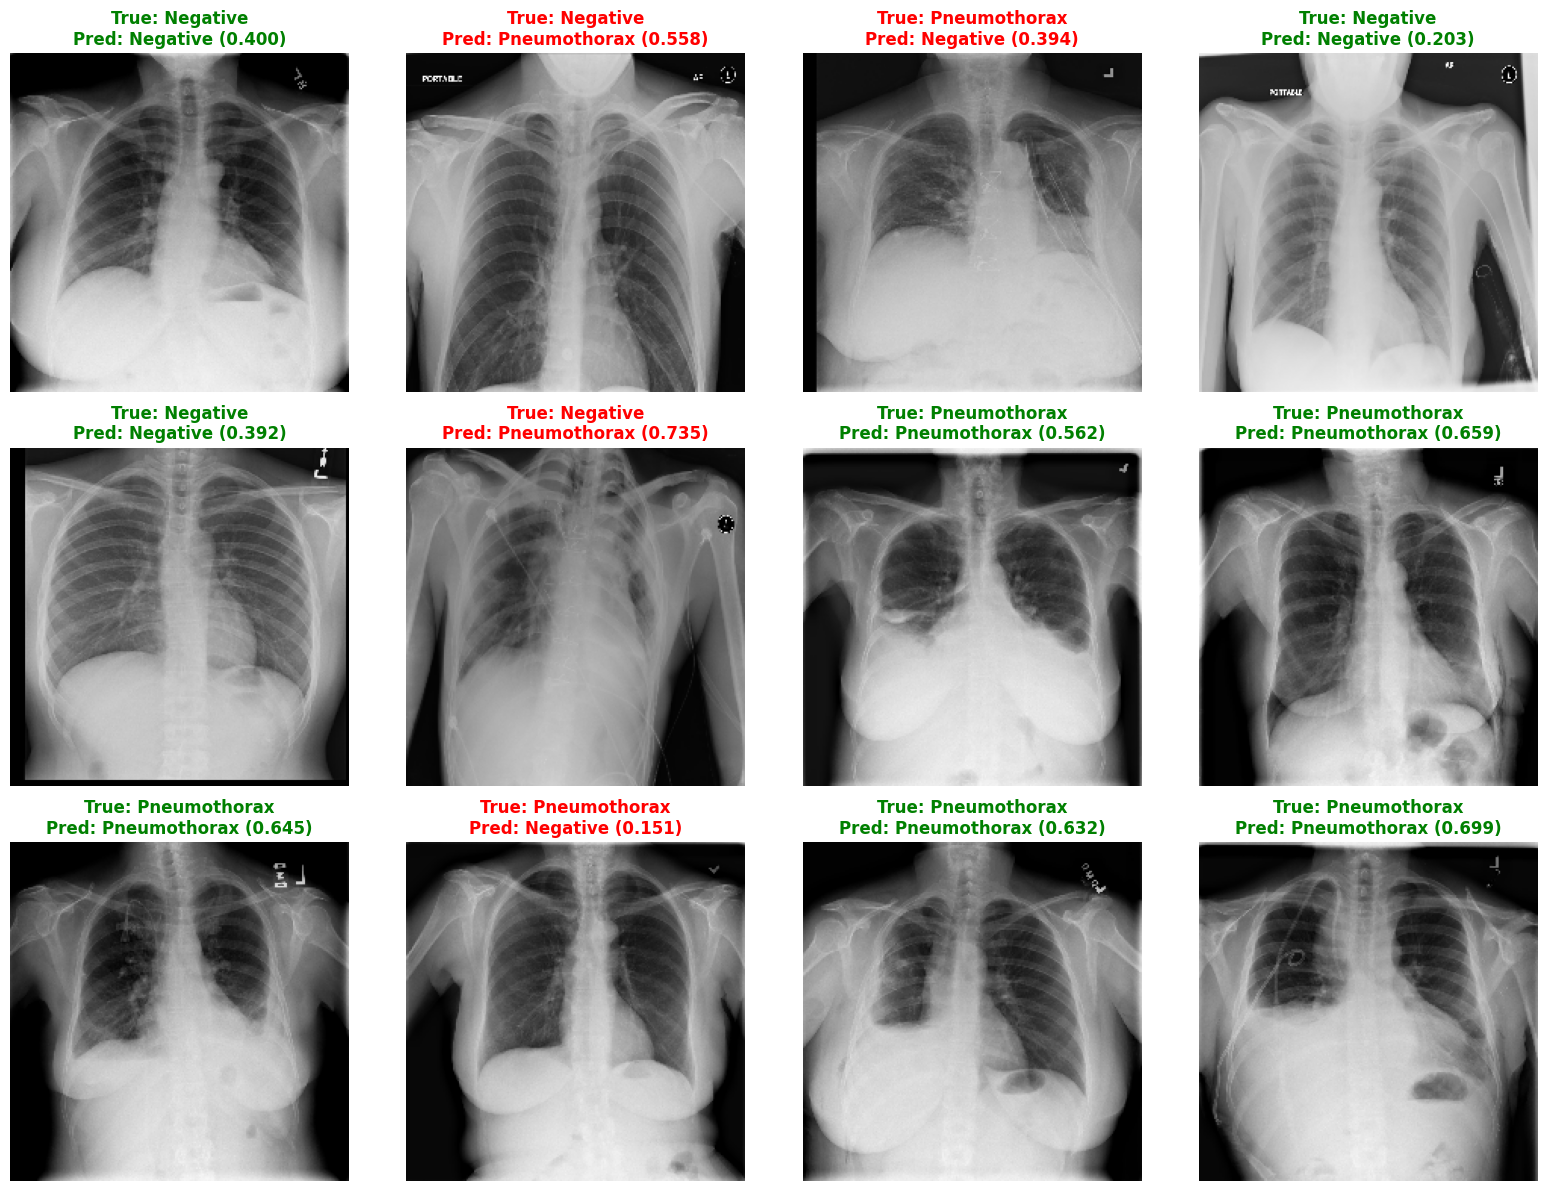

In [14]:
# ============================================================================
# VISUALIZE PREDICTIONS - FIXED
# ============================================================================

def visualize_predictions(test_df, y_pred_probs, n_samples=12):
    """Visualize sample predictions"""
    # Get sample indices
    indices = np.random.choice(len(test_df), n_samples, replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, img_idx in enumerate(indices):
        img_path = test_df.iloc[img_idx]['path']
        true_label = test_df.iloc[img_idx]['binary_label']  # FIXED: Use 'binary_label'
        pred_prob = y_pred_probs[img_idx]  # FIXED: Remove [0] since it's already 1D
        pred_label = 1 if pred_prob > 0.5 else 0
        
        # Load and display image
        img = keras.preprocessing.image.load_img(img_path, target_size=(224,224))
        img_array = keras.preprocessing.image.img_to_array(img)
        
        axes[idx].imshow(img_array.astype('uint8'))
        
        # Create title with prediction info
        true_class = "Pneumothorax" if true_label == 1 else "Negative"
        pred_class = "Pneumothorax" if pred_label == 1 else "Negative"
        color = 'green' if true_label == pred_label else 'red'
        
        title = f"True: {true_class}\nPred: {pred_class} ({pred_prob:.3f})"
        axes[idx].set_title(title, color=color, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('./output/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Get predictions on test set first
print("Generating predictions on test set...")
test_predictions = model.predict(test_dataset, verbose=1)
test_pred_probs = test_predictions.flatten()  # Already 1D

print(f"Test predictions shape: {test_pred_probs.shape}")
print(f"Test dataframe shape: {test_df.shape}")

# Visualize predictions
visualize_predictions(test_df.reset_index(drop=True), test_pred_probs)

In [15]:
# Load best model

# Evaluate on val and test
val_metrics = model.evaluate(val_dataset)
test_metrics = model.evaluate(test_dataset)

print(f"Val AUC: {val_metrics}")
print(f"Test AUC: {test_metrics}")

67/67 [==============================] - 4s 57ms/step - loss: 0.5557 - binary_accuracy: 0.7286 - auc: 0.7950 - precision: 0.7283 - recall: 0.7283
Val AUC: [0.5371760725975037, 0.7339622378349304, 0.8145763278007507, 0.739382266998291, 0.7226415276527405]
Test AUC: [0.5556983947753906, 0.7285579442977905, 0.7950218915939331, 0.7283018827438354, 0.7283018827438354]
